# Skin Disease NLP Classification — BioBERT
**Project:** Multimodal Skin Disease Detection  
**Student:** Mohamed Alhusein Abdalla — BUE AI Department  
**Supervisor:** Dr. Gehad Ismail Sayed  
**Dataset:** Symptom2Disease (filtered to 7 skin classes, 350 samples)  
**Platform:** Vast.ai H200  

---
### Classes (7)
Psoriasis, Chicken pox, Impetigo, Fungal infection, Acne, drug reaction, allergy

---
### Experiments
- **Exp1:** BioBERT fully frozen — only classifier head trained
- **Exp2:** BioBERT partially fine-tuned — top 4 transformer layers + classifier head

---
### Evaluation Protocol
- Stratified 70/15/15 split — BEFORE any oversampling
- Primary metric: Macro F1
- Secondary: Accuracy, AUC-ROC
- Early stopping on Macro F1, patience=10

## Step 0 — Configuration

In [1]:
# ============================================================
# CONFIGURATION
# ============================================================

CSV_PATH   = '/root/Symptom2Disease.csv'

# Skin-relevant classes only
SKIN_CLASSES = [
    'Psoriasis',
    'Chicken pox',
    'Impetigo',
    'Fungal infection',
    'Acne',
    'drug reaction',
    'allergy'
]
NUM_CLASSES = len(SKIN_CLASSES)

# Model
BIOBERT_MODEL = 'dmis-lab/biobert-base-cased-v1.2'
MAX_LEN       = 128

# Split
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# Training
BATCH_SIZE  = 16
NUM_EPOCHS  = 50
LR          = 2e-4    # higher LR for frozen backbone
PATIENCE    = 10
SEED        = 42

# Experiment — change this for Exp2
EXP_NAME    = 'exp1_frozen'
SAVE_DIR    = f'/root/outputs/biobert_{EXP_NAME}'

import os
os.makedirs(SAVE_DIR, exist_ok=True)
print('Config loaded.')
print(f'Classes ({NUM_CLASSES}): {SKIN_CLASSES}')
print(f'BioBERT model: {BIOBERT_MODEL}')
print(f'Experiment: {EXP_NAME}')
print(f'Save dir: {SAVE_DIR}')

Config loaded.
Classes (7): ['Psoriasis', 'Chicken pox', 'Impetigo', 'Fungal infection', 'Acne', 'drug reaction', 'allergy']
BioBERT model: dmis-lab/biobert-base-cased-v1.2
Experiment: exp1_frozen
Save dir: /root/outputs/biobert_exp1_frozen


## Step 1 — Install Libraries

In [2]:
import sys
!{sys.executable} -m pip install -q transformers datasets scikit-learn torchmetrics matplotlib seaborn pandas tqdm

## Step 2 — Imports

In [3]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModel
from torchmetrics.classification import MulticlassF1Score, MulticlassAUROC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: NVIDIA H200
VRAM: 150.1 GB


## Step 3 — Upload & Load Dataset

In [4]:
# Upload Symptom2Disease.csv via JupyterLab file browser to /root/
# then run this cell

df_full = pd.read_csv(CSV_PATH)
print(f'Full dataset shape: {df_full.shape}')

# Filter to skin classes only
df = df_full[df_full['label'].isin(SKIN_CLASSES)].reset_index(drop=True)
df['label_idx'] = df['label'].map({cls: i for i, cls in enumerate(SKIN_CLASSES)})

print(f'Filtered dataset shape: {df.shape}')
print('\nClass distribution:')
print(df['label'].value_counts())
print('\nSample texts:')
for cls in SKIN_CLASSES:
    sample = df[df['label'] == cls]['text'].iloc[0]
    print(f'  [{cls}]: {sample[:100]}...')

Full dataset shape: (1200, 3)
Filtered dataset shape: (350, 4)

Class distribution:
label
Psoriasis           50
Chicken pox         50
Impetigo            50
Fungal infection    50
Acne                50
allergy             50
drug reaction       50
Name: count, dtype: int64

Sample texts:
  [Psoriasis]: I have been experiencing a skin rash on my arms, legs, and torso for the past few weeks. It is red, ...
  [Chicken pox]: I've been experiencing intense itching all over my skin, and it's driving me crazy. I also have a ra...
  [Impetigo]: I have developed a skin rash on my face and neck. The rash is made up of red sores that are blisteri...
  [Fungal infection]: I have raised lumps, a rash that looks red and inflamed, discoloured areas of skin that are differen...
  [Acne]: I've been having a really bad rash on my skin lately. It's full of pus-filled pimples and blackheads...
  [drug reaction]: I have a metallic taste in my mouth, and also have a sense of change of taste and smell. So

## Step 4 — EDA

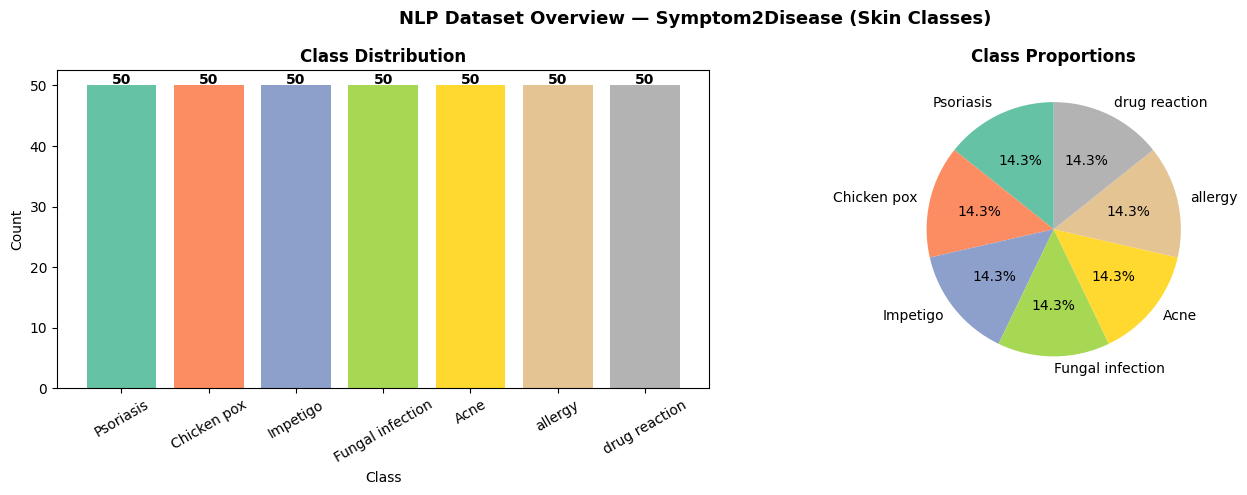

In [5]:
# Class distribution
counts = df['label'].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Class Proportions', fontweight='bold')

plt.suptitle('NLP Dataset Overview — Symptom2Disease (Skin Classes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

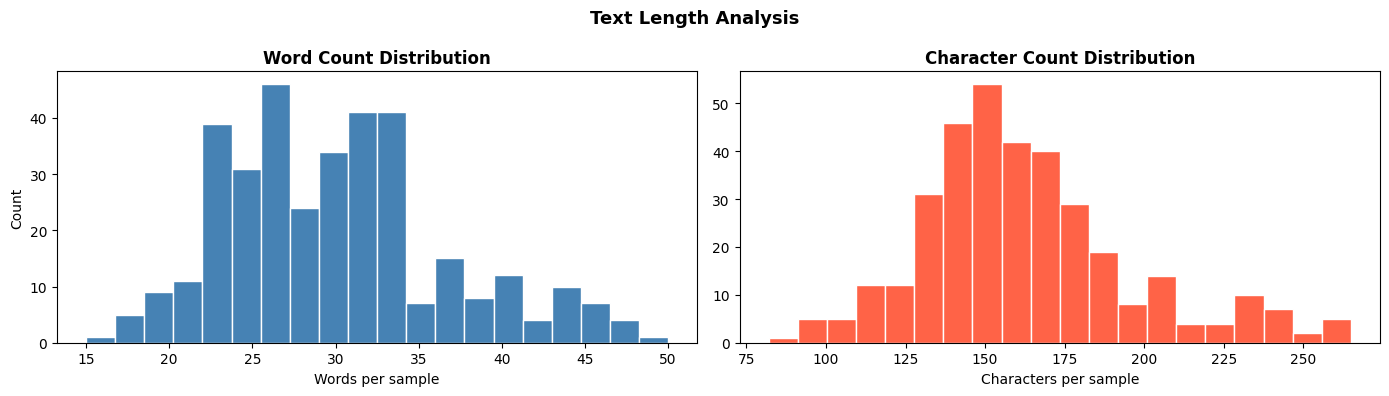

Word count — mean: 29.9, max: 50
Char count — mean: 162.6, max: 265


In [6]:
# Text length distribution
df['word_count'] = df['text'].str.split().str.len()
df['char_count'] = df['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['word_count'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Word Count Distribution', fontweight='bold')
axes[0].set_xlabel('Words per sample')
axes[0].set_ylabel('Count')

axes[1].hist(df['char_count'], bins=20, color='tomato', edgecolor='white')
axes[1].set_title('Character Count Distribution', fontweight='bold')
axes[1].set_xlabel('Characters per sample')

plt.suptitle('Text Length Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/text_length.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Word count — mean: {df["word_count"].mean():.1f}, max: {df["word_count"].max()}')
print(f'Char count — mean: {df["char_count"].mean():.1f}, max: {df["char_count"].max()}')

## Step 5 — Stratified Split (70 / 15 / 15)

In [7]:
# SPLIT BEFORE ANY OVERSAMPLING
texts  = df['text'].to_numpy()
labels = df['label_idx'].to_numpy()

# Step 1: carve out test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    texts, labels, test_size=TEST_RATIO, stratify=labels, random_state=SEED
)

# Step 2: split train / val
val_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_adjusted, stratify=y_trainval, random_state=SEED
)

print(f'Train : {len(X_train):4d} samples')
print(f'Val   : {len(X_val):4d} samples')
print(f'Test  : {len(X_test):4d} samples')
print(f'Total : {len(X_train)+len(X_val)+len(X_test):4d} samples')

print('\nTrain class counts:')
for i, cls in enumerate(SKIN_CLASSES):
    print(f'  {cls:20s}: {(y_train==i).sum()}')
print('\nTest class counts:')
for i, cls in enumerate(SKIN_CLASSES):
    print(f'  {cls:20s}: {(y_test==i).sum()}')

Train :  244 samples
Val   :   53 samples
Test  :   53 samples
Total :  350 samples

Train class counts:
  Psoriasis           : 35
  Chicken pox         : 35
  Impetigo            : 35
  Fungal infection    : 35
  Acne                : 34
  drug reaction       : 35
  allergy             : 35

Test class counts:
  Psoriasis           : 7
  Chicken pox         : 7
  Impetigo            : 8
  Fungal infection    : 8
  Acne                : 8
  drug reaction       : 7
  allergy             : 8


## Step 6 — Tokenizer & Dataset Class

In [8]:
print(f'Loading tokenizer: {BIOBERT_MODEL}')
tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL)
print('Tokenizer loaded.')

class SkinTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long)
        }


train_dataset = SkinTextDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = SkinTextDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = SkinTextDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

Loading tokenizer: dmis-lab/biobert-base-cased-v1.2


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizer loaded.
Train batches: 16
Val batches  : 4
Test batches : 4


## Step 7 — Model (BioBERT + Classifier Head)

In [9]:
class BioBERTClassifier(nn.Module):
    """
    BioBERT encoder + classification head.
    Exp1: backbone fully frozen, only head trained.
    Uses [CLS] token representation as sentence embedding.
    Head: Dropout(0.3) -> Linear(768, 256) -> ReLU -> Linear(256, num_classes)
    """
    def __init__(self, model_name, num_classes, freeze_backbone=True):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)

        if freeze_backbone:
            for param in self.bert.parameters():
                param.requires_grad = False

        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS] token
        return self.classifier(cls_output)


# Exp1: freeze_backbone=True
model = BioBERTClassifier(
    model_name=BIOBERT_MODEL,
    num_classes=NUM_CLASSES,
    freeze_backbone=True
).to(DEVICE)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total_p:,}')
print(f'Trainable params : {trainable_p:,}  (head only)')
print(f'Frozen params    : {total_p - trainable_p:,}  (BioBERT backbone)')

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params     : 108,508,935
Trainable params : 198,663  (head only)
Frozen params    : 108,310,272  (BioBERT backbone)


## Step 8 — Loss, Optimizer, Metrics

In [10]:
criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer  = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)

f1_metric  = MulticlassF1Score(num_classes=NUM_CLASSES, average='macro').to(DEVICE)
auc_metric = MulticlassAUROC(num_classes=NUM_CLASSES, average='macro').to(DEVICE)

print('Loss      : CrossEntropyLoss (label_smoothing=0.1)')
print(f'Optimizer : Adam, LR={LR}')
print('Scheduler : CosineAnnealingLR')
print('Metrics   : Macro F1 (primary), Accuracy, AUC-ROC')

Loss      : CrossEntropyLoss (label_smoothing=0.1)
Optimizer : Adam, LR=0.0002
Scheduler : CosineAnnealingLR
Metrics   : Macro F1 (primary), Accuracy, AUC-ROC


## Step 9 — Train / Eval Functions

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    for batch in tqdm(loader, desc='Train', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        out  = model(input_ids, attention_mask)
        loss = criterion(out, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = out.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.append(preds)
        all_labels.append(labels)

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    return total_loss/total, correct/total, f1_metric(all_preds, all_labels).item()


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    for batch in tqdm(loader, desc='Eval ', leave=False):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        out  = model(input_ids, attention_mask)
        loss = criterion(out, labels)

        total_loss += loss.item() * labels.size(0)
        preds = out.argmax(dim=1)
        probs = torch.softmax(out, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
        all_preds.append(preds)
        all_labels.append(labels)
        all_probs.append(probs)

    all_preds  = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    all_probs  = torch.cat(all_probs)
    macro_f1   = f1_metric(all_preds, all_labels).item()
    macro_auc  = auc_metric(all_probs, all_labels).item()
    return total_loss/total, correct/total, macro_f1, macro_auc, all_preds, all_labels, all_probs


print('Functions defined.')

Functions defined.


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

## Step 10 — Training Loop with Early Stopping

In [12]:
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[],
           'train_f1':[], 'val_f1':[], 'val_auc':[]}

best_val_f1     = 0.0
best_epoch      = 0
patience_ctr    = 0
best_model_path = os.path.join(SAVE_DIR, f'biobert_{EXP_NAME}_best.pt')

print(f'Training — max {NUM_EPOCHS} epochs | early stop patience={PATIENCE}')
print(f'Experiment: {EXP_NAME}\n')

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl_loss, vl_acc, vl_f1, vl_auc, _, _, _ = evaluate(model, val_loader, criterion, DEVICE)

    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)
    history['train_f1'].append(tr_f1)
    history['val_f1'].append(vl_f1)
    history['val_auc'].append(vl_auc)

    print(f'Ep {epoch:02d}/{NUM_EPOCHS} | '
          f'Tr Loss={tr_loss:.4f} Acc={tr_acc:.4f} F1={tr_f1:.4f} | '
          f'Vl Loss={vl_loss:.4f} Acc={vl_acc:.4f} F1={vl_f1:.4f} AUC={vl_auc:.4f}',
          end='')

    if vl_f1 > best_val_f1:
        best_val_f1  = vl_f1
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(model.state_dict(), best_model_path)
        print('  ✓ saved')
    else:
        patience_ctr += 1
        print(f'  (patience {patience_ctr}/{PATIENCE})')
        if patience_ctr >= PATIENCE:
            print(f'\nEarly stop at epoch {epoch}.')
            break

print(f'\nBest Val Macro F1: {best_val_f1:.4f} at epoch {best_epoch}')

Training — max 50 epochs | early stop patience=10
Experiment: exp1_frozen




Train:  94%|█████████▍| 15/16 [00:00<00:00, 33.60it/s]
                                                      
Eval :   0%|          | 0/4 [00:00<?, ?it/s]
                                            

Ep 01/50 | Tr Loss=1.9460 Acc=0.1475 F1=0.1225 | Vl Loss=1.9180 Acc=0.1698 F1=0.0718 AUC=0.8415  ✓ saved



Train:  88%|████████▊ | 14/16 [00:00<00:00, 64.12it/s]
                                                      
Eval :   0%|          | 0/4 [00:00<?, ?it/s]
                                            

Ep 02/50 | Tr Loss=1.9089 Acc=0.2418 F1=0.1960 | Vl Loss=1.8797 Acc=0.3019 F1=0.1692 AUC=0.9040  ✓ saved


...

Ep 21/50 | Tr Loss=1.1540 Acc=0.7951 F1=0.7938 | Vl Loss=1.2394 Acc=0.8113 F1=0.8084 AUC=0.9475  (patience 6/10)


Ep 22/50 | Tr Loss=1.1281 Acc=0.8238 F1=0.8241 | Vl Loss=1.2236 Acc=0.8113 F1=0.8070 AUC=0.9483  (patience 7/10)


Ep 23/50 | Tr Loss=1.1162 Acc=0.8279 F1=0.8288 | Vl Loss=1.2069 Acc=0.8113 F1=0.8054 AUC=0.9499  (patience 8/10)


Ep 24/50 | Tr Loss=1.1143 Acc=0.8361 F1=0.8365 | Vl Loss=1.1903 Acc=0.8113 F1=0.8084 AUC=0.9511  (patience 9/10)


Ep 25/50 | Tr Loss=1.0825 Acc=0.8443 F1=0.8410 | Vl Loss=1.1824 Acc=0.8113 F1=0.8084 AUC=0.9508  (patience 10/10)

Early stop at epoch 25.

Best Val Macro F1: 0.8101 at epoch 15


## Step 11 — Learning Curves

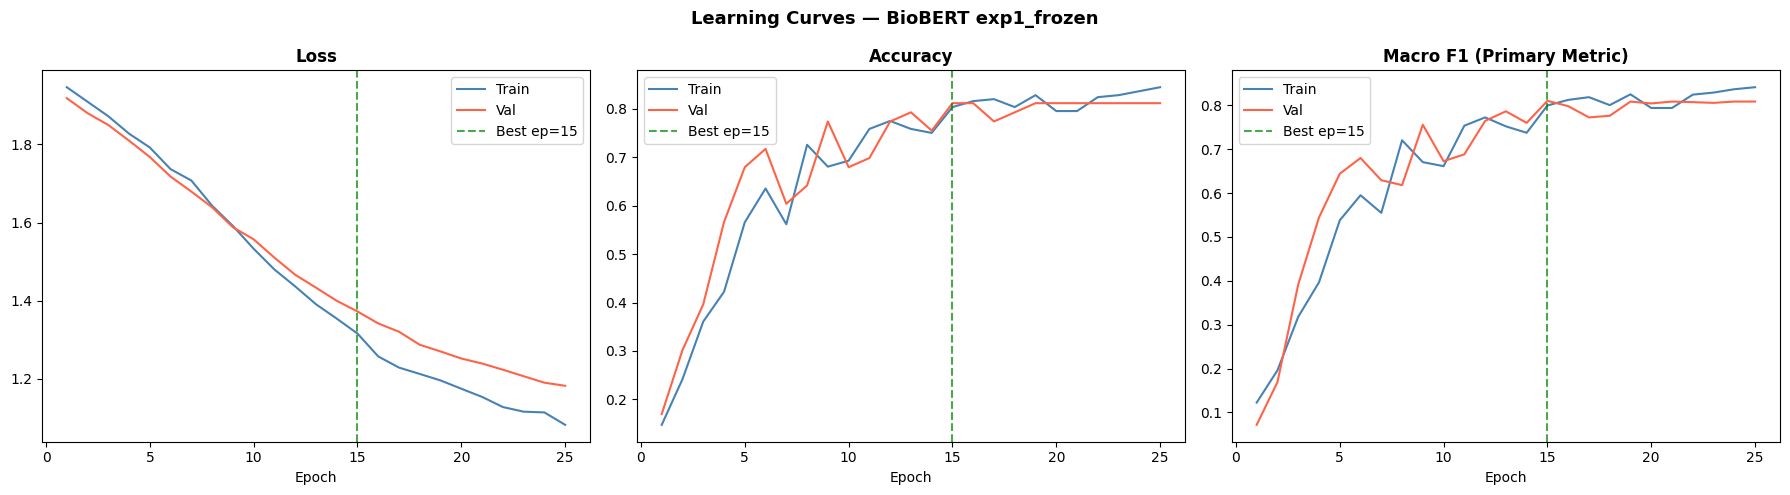

In [13]:
n = len(history['train_loss'])
x = range(1, n + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(
    axes,
    [('train_loss','val_loss'), ('train_acc','val_acc'), ('train_f1','val_f1')],
    ['Loss', 'Accuracy', 'Macro F1 (Primary Metric)']
):
    ax.plot(x, history[metric[0]], label='Train', color='steelblue')
    ax.plot(x, history[metric[1]], label='Val',   color='tomato')
    ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best ep={best_epoch}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle(f'Learning Curves — BioBERT {EXP_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12 — Test Set Evaluation (Best Checkpoint)

In [14]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
print(f'Loaded best model from epoch {best_epoch}')

ts_loss, ts_acc, ts_f1, ts_auc, ts_preds, ts_labels, ts_probs = evaluate(
    model, test_loader, criterion, DEVICE
)

print('\n' + '='*50)
print('TEST SET RESULTS')
print('='*50)
print(f'  Accuracy  : {ts_acc*100:.2f}%')
print(f'  Macro F1  : {ts_f1*100:.2f}%   <- PRIMARY METRIC')
print(f'  AUC-ROC   : {ts_auc*100:.2f}%')
print(f'  Loss      : {ts_loss:.4f}')
print('='*50)

Loaded best model from epoch 15



TEST SET RESULTS
  Accuracy  : 77.36%
  Macro F1  : 75.67%   <- PRIMARY METRIC
  AUC-ROC   : 94.22%
  Loss      : 1.3022


## Step 13 — Classification Report (Per-Class)

In [15]:
ts_preds_np  = ts_preds.cpu().numpy()
ts_labels_np = ts_labels.cpu().numpy()

report = classification_report(ts_labels_np, ts_preds_np, target_names=SKIN_CLASSES, digits=4)
print(report)

with open(f'{SAVE_DIR}/classification_report.txt', 'w') as f:
    f.write(f'Model: BioBERT {EXP_NAME}\nBest epoch: {best_epoch}\n')
    f.write(f'Test Accuracy : {ts_acc*100:.2f}%\n')
    f.write(f'Test Macro F1 : {ts_f1*100:.2f}%\n')
    f.write(f'Test AUC-ROC  : {ts_auc*100:.2f}%\n\n')
    f.write(report)
print(f'Saved to {SAVE_DIR}/classification_report.txt')

                  precision    recall  f1-score   support

       Psoriasis     0.6667    0.8571    0.7500         7
     Chicken pox     0.8333    0.7143    0.7692         7
        Impetigo     0.8333    0.6250    0.7143         8
Fungal infection     1.0000    1.0000    1.0000         8
            Acne     1.0000    1.0000    1.0000         8
   drug reaction     0.5000    0.2857    0.3636         7
         allergy     0.5833    0.8750    0.7000         8

        accuracy                         0.7736        53
       macro avg     0.7738    0.7653    0.7567        53
    weighted avg     0.7799    0.7736    0.7640        53

Saved to /root/outputs/biobert_exp1_frozen/classification_report.txt


## Step 14 — Confusion Matrix

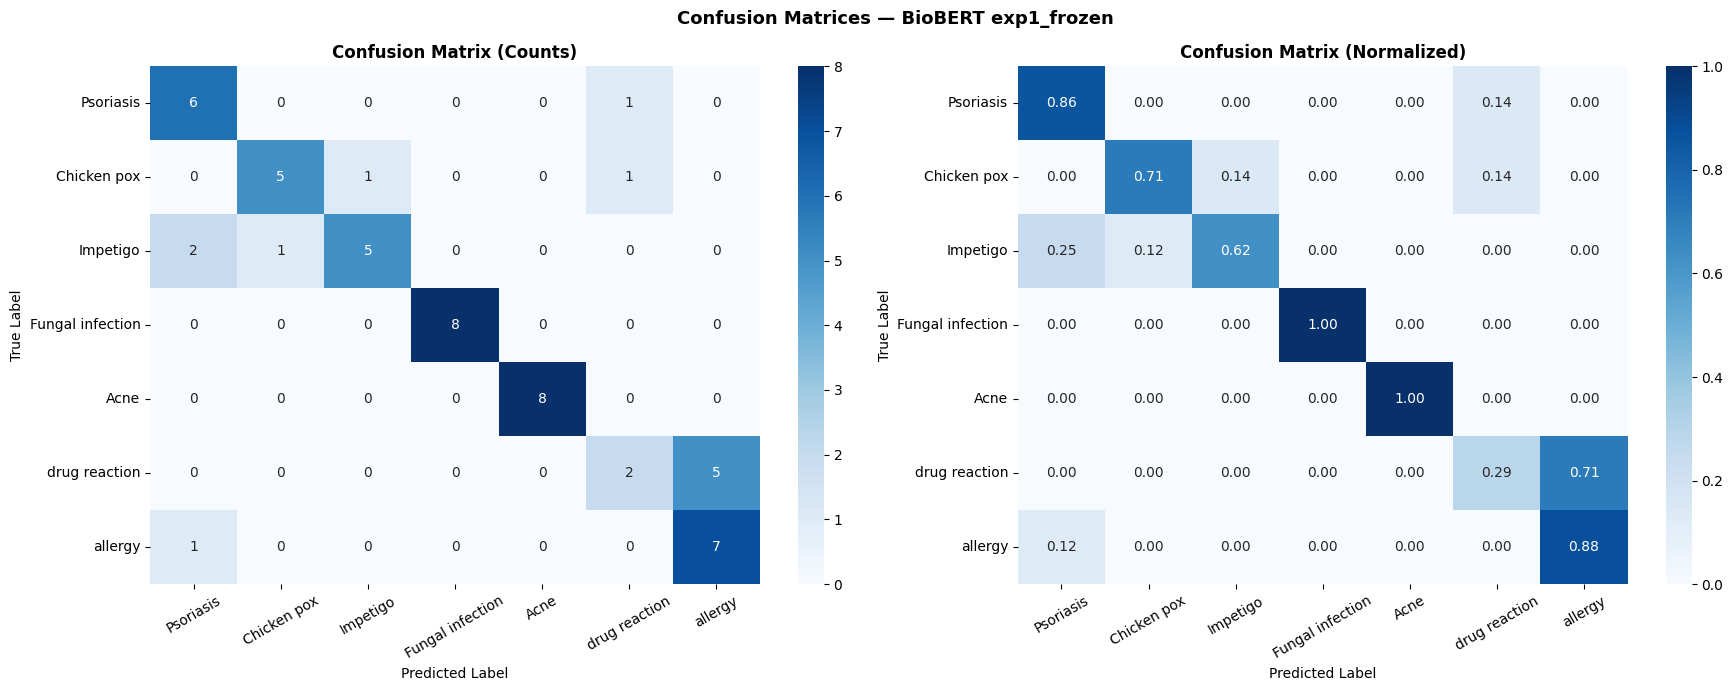

In [16]:
cm      = confusion_matrix(ts_labels_np, ts_preds_np)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Counts', 'Normalized']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=SKIN_CLASSES, yticklabels=SKIN_CLASSES, ax=ax)
    ax.set_title(f'Confusion Matrix ({title})', fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(f'Confusion Matrices — BioBERT {EXP_NAME}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 15 — ROC Curves

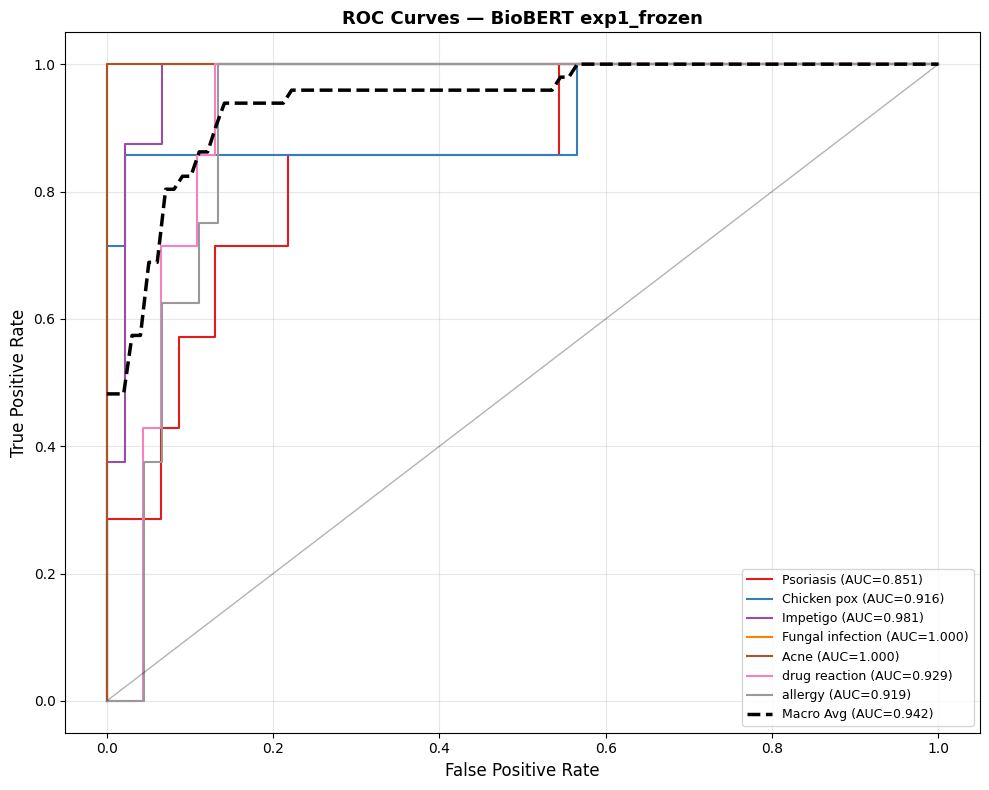

In [17]:
ts_probs_np = ts_probs.cpu().numpy()
y_bin       = label_binarize(ts_labels_np, classes=list(range(NUM_CLASSES)))
colors      = plt.cm.Set1(np.linspace(0, 1, NUM_CLASSES))
mean_fpr    = np.linspace(0, 1, 100)
tprs        = []

fig, ax = plt.subplots(figsize=(10, 8))
for i, (cls, color) in enumerate(zip(SKIN_CLASSES, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], ts_probs_np[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{cls} (AUC={roc_auc:.3f})')
    tprs.append(np.interp(mean_fpr, fpr, tpr))

mean_tpr = np.mean(tprs, axis=0)
ax.plot(mean_fpr, mean_tpr, 'k--', lw=2.5,
        label=f'Macro Avg (AUC={auc(mean_fpr, mean_tpr):.3f})')
ax.plot([0,1],[0,1],'k-', lw=1, alpha=0.3)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title(f'ROC Curves — BioBERT {EXP_NAME}', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 16 — Final Summary

In [18]:
print('\n' + '='*60)
print(f'  FINAL RESULTS — BioBERT {EXP_NAME.upper()}')
print('='*60)
print(f'  Dataset       : Symptom2Disease (7 skin classes, 350 samples)')
print(f'  Split         : Stratified 70/15/15')
print(f'  Model         : BioBERT (dmis-lab/biobert-base-cased-v1.2)')
print(f'  Backbone      : Frozen (head only trained)')
print(f'  Best epoch    : {best_epoch}')
print('-'*60)
print(f'  Test Accuracy : {ts_acc*100:.2f}%')
print(f'  Test Macro F1 : {ts_f1*100:.2f}%   <- PRIMARY')
print(f'  Test AUC-ROC  : {ts_auc*100:.2f}%')
print('-'*60)
print(f'  Val Macro F1  : {best_val_f1*100:.2f}%  (checkpoint selection)')
print('='*60)
print(f'\nAll outputs saved to: {SAVE_DIR}')


  FINAL RESULTS — BioBERT EXP1_FROZEN
  Dataset       : Symptom2Disease (7 skin classes, 350 samples)
  Split         : Stratified 70/15/15
  Model         : BioBERT (dmis-lab/biobert-base-cased-v1.2)
  Backbone      : Frozen (head only trained)
  Best epoch    : 15
------------------------------------------------------------
  Test Accuracy : 77.36%
  Test Macro F1 : 75.67%   <- PRIMARY
  Test AUC-ROC  : 94.22%
------------------------------------------------------------
  Val Macro F1  : 81.01%  (checkpoint selection)

All outputs saved to: /root/outputs/biobert_exp1_frozen
